<h1><b>Assessing Emoji Semantic Drift and Its Impact on Short-Text Sentiment Classification(Using Twitter Dataset)</b></h1>

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("backhand_index_pointing_right.csv",
    engine="python",        # safer for messy text
    encoding="utf-8",
    on_bad_lines="skip")

In [9]:

# Explicitly define the emoji
emoji = "👉"


# Tweet column name
tweet_column = "Text"

# Filter tweets that contain the emoji
filtered_df = df[df[tweet_column].astype(str).str.contains(emoji, regex=False)]

# Create output DataFrame
result = pd.DataFrame({
    "emoji": [emoji] * len(filtered_df),
    "tweet": filtered_df[tweet_column].values
})

# Save extracted data
result.to_csv(
    "backhand_index_pointing_right_extracted.csv",
    index=False,
    encoding="utf-8"
)

print(f"Extracted {len(result)} tweets containing {emoji}")


Extracted 19157 tweets containing 👉


In [10]:
df.head()

,Text
0,🧡@KeplerHomes AirdropBox event for #Arbitrum e...
1,"Remember, success in online business is a mara..."
2,@occupied_9 @Rhiannon_clare_ @FightHaven Thank...
3,Hungry for active mutuals👬👭? Follow fastest Re...
4,📢 It's confirmed. Whitelist for Shardeum Airdr...


In [12]:
import pandas as pd
import os

input_folder = "x_data"
output_folder = "extracted_data"

os.makedirs(output_folder, exist_ok=True)


emoji_map = {
    "backhand_index_pointing_right": "👉",
    "check_mark": "✔️",
    "check_mark_button": "✅",
    "clown_face": "🤡",
    "cooking": "🍳",
    "egg": "🥚",
    "enraged_face": "😡",
    "eyes": "👀",
    "face_holding_back_tears": "🥹",
    "face_savoring_food": "😋",
    "face_with_steam_from_nose": "😤",
    "face_with_tears_of_joy": "😂",
    "fearful_face": "😨",
    "fire": "🔥",
    "folded_hands": "🙏",
    "ghost": "👻",
    "grinning_face_with_sweat": "😅",
    "hatching_chick": "🐣",
    "hot_face": "🥵",
    "loudly_crying_face": "😭",
    "melting_face": "🫠",
    "middle_finger": "🖕",
    "party_popper": "🎉",
    "partying_face": "🥳",
    "pile_of_poo": "💩",
    "rabbit": "🐰",
    "rabbit_face": "🐰",
    "red_heart": "❤️",
    "rolling_on_the_floor_laughing": "🤣",
    "saluting_face": "🫡",
    "skull": "💀",
    "smiling_face": "😊",
    "smiling_face_with_halo": "😇",
    "smiling_face_with_heart-eyes": "😍",
    "smiling_face_with_hearts": "🥰",
    "smiling_face_with_sunglasses": "😎",
    "smiling_face_with_tear": "🥲",
    "sparkles": "✨",
    "sun": "☀️",
    "thinking_face": "🤔",
    "thumbs_up": "👍",
    "white_heart": "🤍",
    "winking_face": "😉"
}


tweet_column = "Text"

for file in os.listdir(input_folder):
    if not file.endswith(".csv"):
        continue

    emoji_name = os.path.splitext(file)[0]

    # Skip if emoji is not defined
    if emoji_name not in emoji_map:
        print(f"Skipping {file} (emoji not found)")
        continue

    emoji = emoji_map[emoji_name]
    file_path = os.path.join(input_folder, file)

    try:
        df = pd.read_csv(
            file_path,
            engine="python",
            encoding="utf-8",
            on_bad_lines="skip"
        )

        if tweet_column not in df.columns:
            print(f"Skipping {file} (no text column)")
            continue

        filtered_df = df[df[tweet_column].astype(str).str.contains(emoji, regex=False)]

        if filtered_df.empty:
            print(f"No tweets found for {emoji}")
            continue

        result = pd.DataFrame({
            "emoji": [emoji] * len(filtered_df),
            "tweet": filtered_df[tweet_column].values
        })

        output_file = os.path.join(
            output_folder, f"{emoji_name}_extracted.csv"
        )

        result.to_csv(output_file, index=False, encoding="utf-8")
        print(f"✔ Processed {file} ({len(result)} tweets)")

    except Exception as e:
        print(f"❌ Error processing {file}: {e}")


✔ Processed backhand_index_pointing_right.csv (19157 tweets)
✔ Processed check_mark.csv (19989 tweets)
✔ Processed check_mark_button.csv (19998 tweets)
✔ Processed clown_face.csv (19145 tweets)
✔ Processed cooking.csv (6438 tweets)
✔ Processed egg.csv (18146 tweets)
✔ Processed enraged_face.csv (19734 tweets)
✔ Processed eyes.csv (19264 tweets)
✔ Processed face_holding_back_tears.csv (19669 tweets)
✔ Processed face_savoring_food.csv (18941 tweets)
✔ Processed face_with_steam_from_nose.csv (19103 tweets)
✔ Processed face_with_tears_of_joy.csv (19961 tweets)
✔ Processed fearful_face.csv (19750 tweets)
✔ Processed fire.csv (16730 tweets)
✔ Processed folded_hands.csv (19330 tweets)
✔ Processed ghost.csv (6953 tweets)
✔ Processed grinning_face_with_sweat.csv (19939 tweets)
✔ Processed hatching_chick.csv (19361 tweets)
✔ Processed hot_face.csv (18230 tweets)
✔ Processed loudly_crying_face.csv (19937 tweets)
✔ Processed melting_face.csv (19086 tweets)
✔ Processed middle_finger.csv (17315 twee

<p>Uplit now we have cleaned the csv files and now each csv has two columns <b>emoji</b> and <b>tweet</b></p>

<h3>Merging All CSVs into One Master Dataset</h3>

In [14]:
import pandas as pd
import os

input_folder = "extracted_data"  # your cleaned CSV folder
all_files = [f for f in os.listdir(input_folder) if f.endswith(".csv")]

dfs = []
for file in all_files:
    df = pd.read_csv(os.path.join(input_folder, file))
    dfs.append(df)

# Merge all into one DataFrame
master_df = pd.concat(dfs, ignore_index=True)

# Save master dataset
master_df.to_csv("all_emojis_master.csv", index=False, encoding="utf-8")
print(f"Master dataset created with {len(master_df)} tweets")

Master dataset created with 734286 tweets


In [15]:
master_df.head()

,emoji,tweet
0,👉,🧡@KeplerHomes AirdropBox event for #Arbitrum e...
1,👉,"Remember, success in online business is a mara..."
2,👉,@occupied_9 @Rhiannon_clare_ @FightHaven Thank...
3,👉,📢 It's confirmed. Whitelist for Shardeum Airdr...
4,👉,7/ What to do next?\n\n-Using these bridges:\n...


<h3>Cleaning Tweets for NLP</h3>

In [16]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)          # remove mentions
    text = re.sub(r"#\w+", "", text)          # remove hashtags
    text = text.replace("\n", " ").strip()
    return text

master_df['clean_tweet'] = master_df['tweet'].apply(clean_text)

In [17]:
# Assuming master_df has columns: 'emoji' and 'tweet'

# Create a reverse map: emoji → name
reverse_emoji_map = {v: k for k, v in emoji_map.items()}

# Add emoji_name column
master_df['emoji_name'] = master_df['emoji'].map(reverse_emoji_map)

# Save updated CSV
master_df.to_csv("master_with_names.csv", index=False, encoding="utf-8")

In [18]:
master_df.head()

,emoji,tweet,clean_tweet,emoji_name
0,👉,🧡@KeplerHomes AirdropBox event for #Arbitrum e...,🧡 AirdropBox event for ecological users is he...,backhand_index_pointing_right
1,👉,"Remember, success in online business is a mara...","Remember, success in online business is a mara...",backhand_index_pointing_right
2,👉,@occupied_9 @Rhiannon_clare_ @FightHaven Thank...,Thanks for the update the sh*t country the sh*...,backhand_index_pointing_right
3,👉,📢 It's confirmed. Whitelist for Shardeum Airdr...,📢 It's confirmed. Whitelist for Shardeum Airdr...,backhand_index_pointing_right
4,👉,7/ What to do next?\n\n-Using these bridges:\n...,7/ What to do next? -Using these bridges: 👉 (...,backhand_index_pointing_right


In [19]:
# Keep only relevant columns
master_df = master_df[['emoji', 'emoji_name', 'clean_tweet']]

# rename for clarity
master_df.rename(columns={'clean_tweet': 'tweet'}, inplace=True)

In [21]:
# Save the cleaned master CSV
master_df.to_csv("master_cleaned.csv", index=False, encoding="utf-8")
# Check the first few rows
master_df.head()

,emoji,emoji_name,tweet
0,👉,backhand_index_pointing_right,🧡 AirdropBox event for ecological users is he...
1,👉,backhand_index_pointing_right,"Remember, success in online business is a mara..."
2,👉,backhand_index_pointing_right,Thanks for the update the sh*t country the sh*...
3,👉,backhand_index_pointing_right,📢 It's confirmed. Whitelist for Shardeum Airdr...
4,👉,backhand_index_pointing_right,7/ What to do next? -Using these bridges: 👉 (...


<h1>Semantic Drift PipeLine</h1>

In [43]:
# Shuffle the master dataset to randomize tweets
master_df = master_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Create two simulated time slices: 2025 and 2026
half = len(master_df) // 2

# First half → 2025
master_df.loc[:half-1, 'time_slice'] = 2024  

# Second half → 2026
master_df.loc[half:, 'time_slice'] = 2025  

# Check distribution
print(master_df['time_slice'].value_counts())

time_slice
2024.0    367143
2025.0    367143
Name: count, dtype: int64


In [39]:
!pip install pandas numpy gensim scikit-learn matplotlib tqdm

In [44]:
import pandas as pd
import numpy as np
import re
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [45]:
master_df = pd.read_csv("master_cleaned.csv")

In [46]:
#Simulate two time slices (2025 and 2026) since only one exists
master_df = master_df.sample(frac=1, random_state=42).reset_index(drop=True)
half = len(master_df) // 2
master_df.loc[:half-1, 'time_slice'] = 2024
master_df.loc[half:, 'time_slice'] = 2025

In [47]:
print(master_df['time_slice'].value_counts())

time_slice
2024.0    367143
2025.0    367143
Name: count, dtype: int64


<h3><b>Tokeinization and preprocessing</b></h3>

In [48]:
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)          # remove mentions
    text = re.sub(r"#\w+", "", text)          # remove hashtags
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove punctuation
    tokens = text.split()
    return tokens

master_df['tokens'] = master_df['tweet'].apply(tokenize)

In [49]:
#  Prepare for Word2Vec
time_slices = sorted(master_df['time_slice'].unique())
emoji_names = master_df['emoji_name'].unique()

In [50]:
# Train Word2Vec per time slice
slice_models = {}
for ts in time_slices:
    slice_tweets = master_df[master_df['time_slice'] == ts]['tokens'].tolist()
    if len(slice_tweets) == 0:
        continue
    model = Word2Vec(sentences=slice_tweets, vector_size=100, window=5, min_count=2, workers=4, sg=1)
    slice_models[ts] = model
print("✅ Word2Vec models trained for all slices")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

✅ Word2Vec models trained for all slices


In [51]:
#Compute emoji embeddings per slice
emoji_embeddings = {}
for ts in time_slices:
    if ts not in slice_models:
        continue
    model = slice_models[ts]
    emoji_embeddings[ts] = {}
    for emoji in emoji_names:
        tweets_tokens = master_df[(master_df['emoji_name'] == emoji) &
                                  (master_df['time_slice'] == ts)]['tokens'].tolist()
        all_words = [word for tweet in tweets_tokens for word in tweet if word in model.wv]
        if len(all_words) == 0:
            embedding = np.zeros(model.vector_size)
        else:
            embedding = np.mean([model.wv[word] for word in all_words], axis=0)
        emoji_embeddings[ts][emoji] = embedding

print("✅ Emoji embeddings computed for each slice")

✅ Emoji embeddings computed for each slice


In [54]:
 #Compute semantic drift (modern pandas)
drift_rows = []  # collect rows as dictionaries first

for i in range(len(time_slices)-1):
    ts1 = time_slices[i]
    ts2 = time_slices[i+1]
    for emoji in emoji_names:
        emb1 = emoji_embeddings[ts1][emoji].reshape(1, -1)
        emb2 = emoji_embeddings[ts2][emoji].reshape(1, -1)
        sim = cosine_similarity(emb1, emb2)[0][0]
        
        drift_rows.append({
            'emoji_name': emoji,
            'time_slice_1': ts1,
            'time_slice_2': ts2,
            'cosine_similarity': sim
        })

# Convert list of dicts to DataFrame
drift_results = pd.DataFrame(drift_rows)
print("✅ Semantic drift computed")

✅ Semantic drift computed


In [55]:
#  Function to get top words representing current meaning
def top_words_for_emoji(emoji_name, ts, top_n=10):
    if ts not in slice_models or emoji_name not in emoji_embeddings[ts]:
        return []
    model = slice_models[ts]
    emb = emoji_embeddings[ts][emoji_name].reshape(1,-1)
    words = list(model.wv.index_to_key)
    sims = [(word, cosine_similarity(emb, model.wv[word].reshape(1,-1))[0][0]) for word in words]
    sims_sorted = sorted(sims, key=lambda x: x[1], reverse=True)
    return sims_sorted[:top_n]

In [56]:
# Example: Top words for emoji "face_with_tears_of_joy" in latest slice
latest_ts = max(time_slices)
print("Top words for 😂 in latest slice:", top_words_for_emoji("face_with_tears_of_joy", latest_ts))

Top words for 😂 in latest slice: [('regulars', np.float32(0.92480874)), ('ehhh', np.float32(0.92061734)), ('lols', np.float32(0.9202579)), ('passionately', np.float32(0.917238)), ('digress', np.float32(0.9153064)), ('tras', np.float32(0.91425806)), ('yal', np.float32(0.91315067)), ('amnesia', np.float32(0.9125963)), ('upsets', np.float32(0.9115313)), ('adulting', np.float32(0.91009045))]


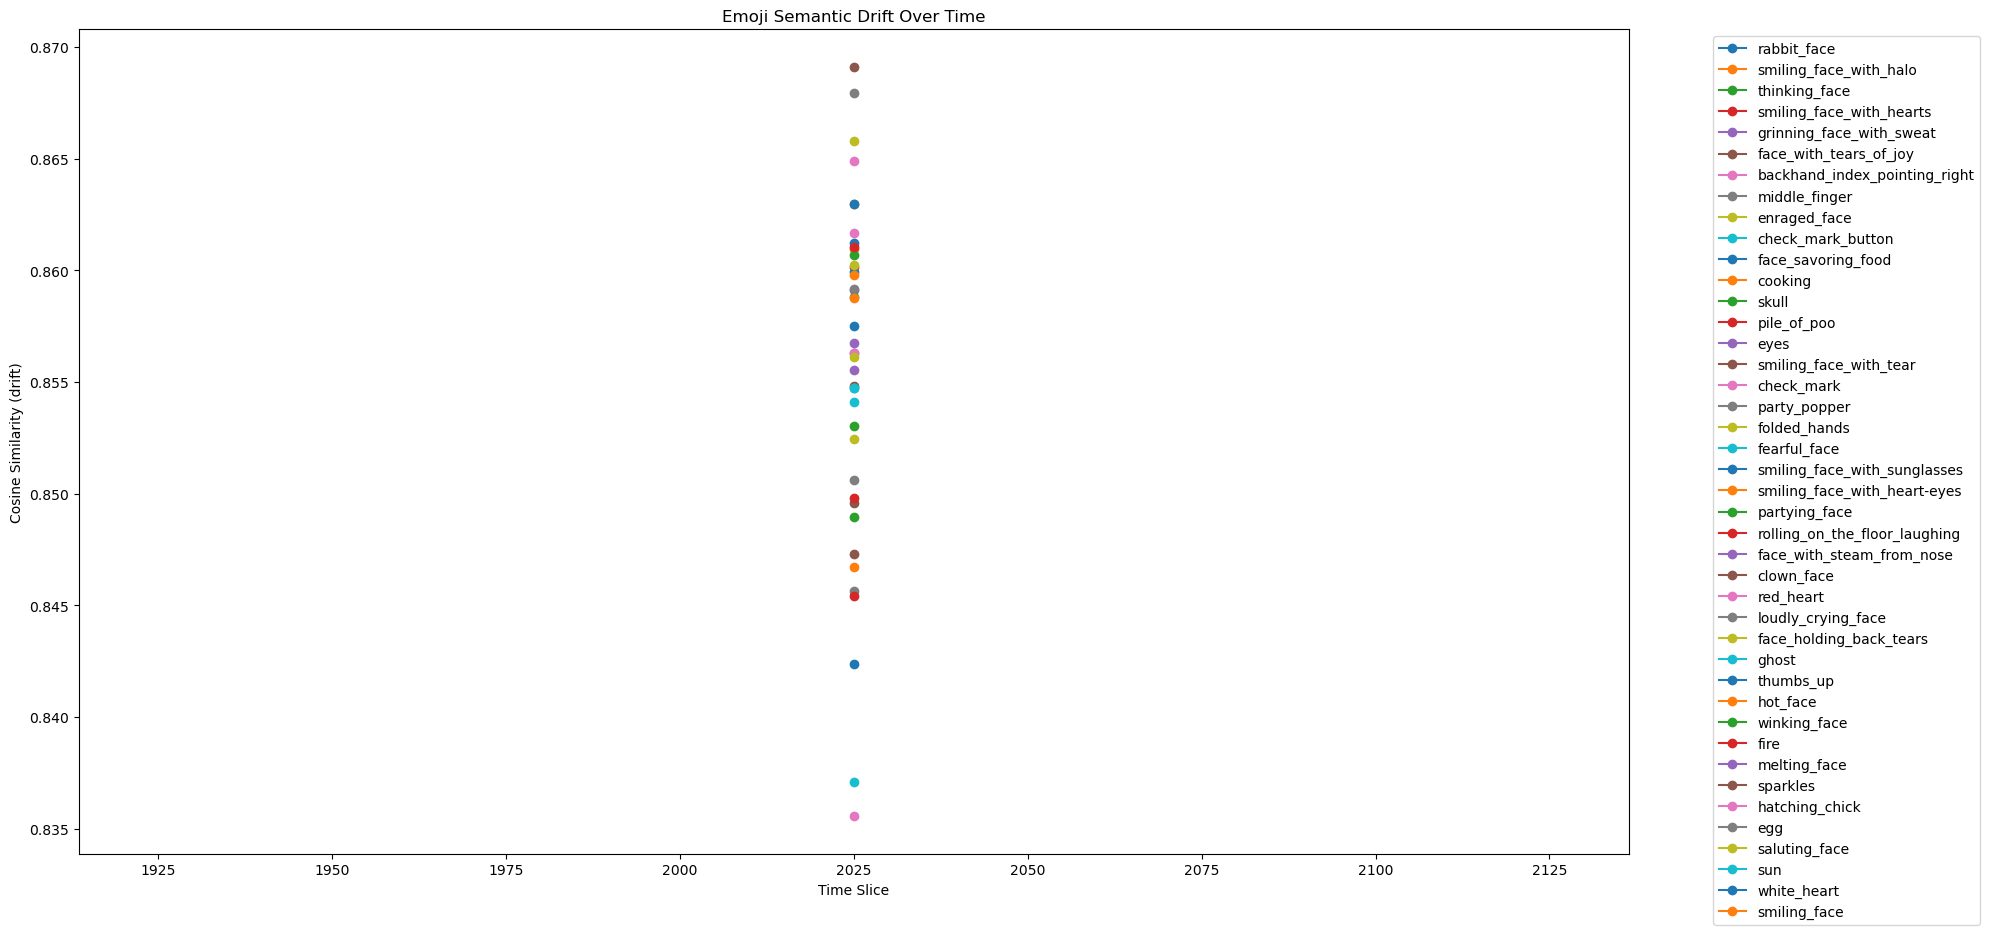

In [62]:
#  Visualize drift trajectories
plt.figure(figsize=(20,10))
for emoji in emoji_names:
    df = drift_results[drift_results['emoji_name']==emoji]
    if df.empty:
        continue
    plt.plot(df['time_slice_2'], df['cosine_similarity'], marker='o', label=emoji)
plt.xlabel("Time Slice")
plt.ylabel("Cosine Similarity (drift)")
plt.title("Emoji Semantic Drift Over Time")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()